BASIC HODGKIN-HUXLEY MODEL

In [1]:
# import necesary libraries
import numpy as np
import matplotlib.pyplot as plt



In [2]:
# hodgkin-huxley prarmeters
c_m = 1.0  # membrane capacitance, in uF/cm^2
g_Na = 120.0  # maximum  sodium conducances, in mS/cm^2
g_K = 36.0  # maximum potassium conducances, in mS/cm^2
g_L = 0.3  # maximum leak conducances, in mS/cm^

E_Na = 50.0  # sodium Nernst reversal potentials, in mV
E_K = -77.0  # potassium Nernst reversal potentials, in mV
E_L = -54.387  # leak Nernst reversal potentials, in mV

In [3]:
# simulation parameters
dt = 0.01             # ms
T = 100.0             # ms

time = np.arange(0.0, T + dt, dt)  # time array

In [4]:
# H-H gating functions
def alpha_m(V):
    return 0.1 * (V + 40.0) / (1.0 - np.exp(-(V + 40.0) / 10.0))

def beta_m(V):
    return 4.0 * np.exp(-(V + 65.0) / 18.0)

def alpha_h(V):
    return 0.07 * np.exp(-(V + 65.0) / 20.0)

def beta_h(V):
    return 1.0 / (1.0 + np.exp(-(V + 35.0) / 10.0))

def alpha_n(V):
    return 0.01 * (V + 55.0) / (1.0 - np.exp(-(V + 55.0) / 10.0))

def beta_n(V):
    return 0.125 * np.exp(-(V + 65) / 80.0)

In [5]:
# initial conditions

V = np.zeros(len(time))  # membrane potential array

m = np.zeros(len(time))  # sodium activation gating variable
h = np.zeros(len(time))  # sodium inactivation gating variable
n = np.zeros(len(time))  # potassium activation gating variable

V[0] = -65.0 # initial membrane potential, in mV
m[0] = alpha_m(V[0]) / (alpha_m(V[0]) + beta_m(V[0]))
h[0] = alpha_h(V[0]) / (alpha_h(V[0]) + beta_h(V[0]))
n[0] = alpha_n(V[0]) / (alpha_n(V[0]) + beta_n(V[0]))


In [6]:
# External current (Constant)
I_ext = 10.0  # in μA/cm^2

In [7]:
# H-H simulation

for i in range(1, len(time)):

    # Ionic currents
    I_Na = g_Na * m[i-1]**3 * h[i-1] * (V[i-1] - E_Na)

    I_K = g_K * n[i-1]**4 * (V[i-1] - E_K)

    I_L = g_L * (V[i-1] - E_L)


    # Membrane potential
    dVdt = (I_ext - I_Na - I_K - I_L) / c_m

    V[i] = V[i-1] + dt * dVdt


    # Gating variables

    dm_dt = (
        alpha_m(V[i-1]) * (1.0 - m[i-1])
        - beta_m(V[i-1]) * m[i-1]
    )

    dh_dt = (
        alpha_h(V[i-1]) * (1.0 - h[i-1])
        - beta_h(V[i-1]) * h[i-1]
    )

    dn_dt = (
        alpha_n(V[i-1]) * (1.0 - n[i-1])
        - beta_n(V[i-1]) * n[i-1]
    )


    m[i] = m[i-1] + dt * dm_dt
    h[i] = h[i-1] + dt * dh_dt
    n[i] = n[i-1] + dt * dn_dt

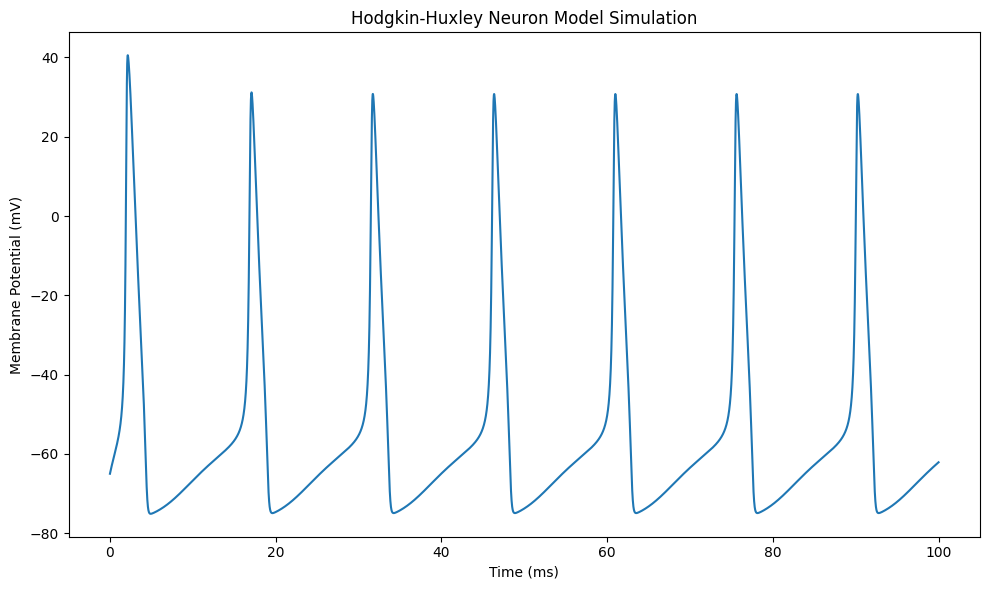

In [8]:
# plot membrane potential
plt.figure(figsize=(10, 6))
plt.plot(time, V, label='Membrane Potential (mV)')
plt.title('Hodgkin-Huxley Neuron Model Simulation')
plt.xlabel('Time (ms)')
plt.ylabel('Membrane Potential (mV)')
plt.tight_layout()
plt.show()
plt.close()

WITH STEP CURRENT

In [9]:
I_ext = np.zeros(len(time))

stimulus = (time >= 10) & (time <= 80)  # Stimulus from 10 ms to 80 ms
I_ext[stimulus] = 10.0  # Apply external current of 10 μA/cm^2 during the stimulus period

In [10]:
for i in range(1, len(time)):

    # Current applied at this time step
    I = I_ext[i]

    # Ionic currents
    I_Na = g_Na * m[i-1]**3 * h[i-1] * (V[i-1] - E_Na)

    I_K = g_K * n[i-1]**4 * (V[i-1] - E_K)

    I_L = g_L * (V[i-1] - E_L)

    # Membrane potential
    dVdt = (I - I_Na - I_K - I_L) / c_m

    V[i] = V[i-1] + dt * dVdt

    # Gating variables
    dm_dt = (
        alpha_m(V[i-1]) * (1.0 - m[i-1])
        - beta_m(V[i-1]) * m[i-1]
    )

    dh_dt = (
        alpha_h(V[i-1]) * (1.0 - h[i-1])
        - beta_h(V[i-1]) * h[i-1]
    )

    dn_dt = (
        alpha_n(V[i-1]) * (1.0 - n[i-1])
        - beta_n(V[i-1]) * n[i-1]
    )

    m[i] = m[i-1] + dt * dm_dt
    h[i] = h[i-1] + dt * dh_dt
    n[i] = n[i-1] + dt * dn_dt

Plot input potential

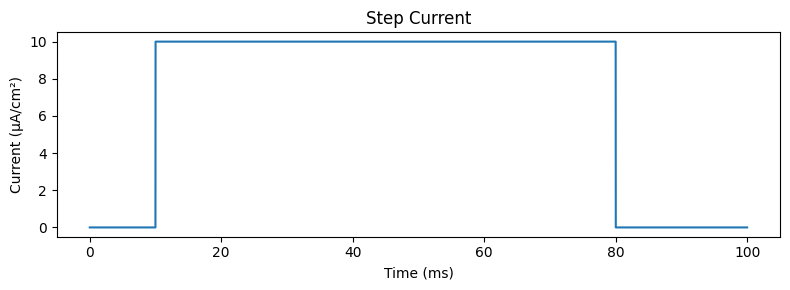

In [11]:
plt.figure(figsize=(8, 3))

plt.plot(time, I_ext)

plt.xlabel("Time (ms)")
plt.ylabel("Current (µA/cm²)")
plt.title("Step Current")
plt.tight_layout()
plt.show()
plt.close()

PLOT MEMBRANE POTENTIAL

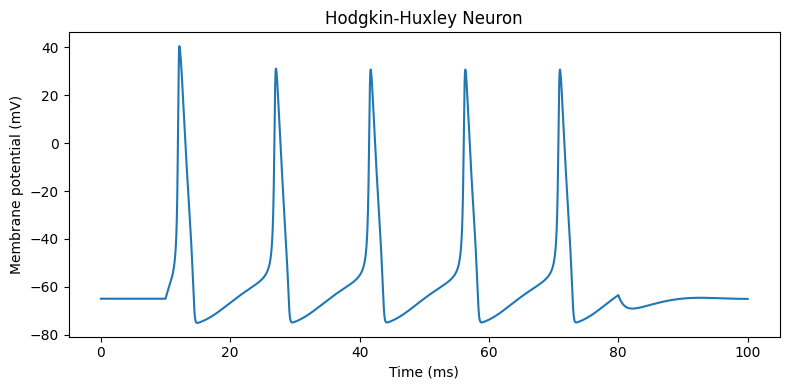

In [12]:

plt.figure(figsize=(8, 4))
plt.plot(time, V)
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.title("Hodgkin-Huxley Neuron")
plt.tight_layout()
plt.show()

ADD VARIABLE CURRENT

In [13]:
np.random.seed(42)

I_ext = np.zeros(len(time))

# Stimulus period
stimulus = (time >= 10.0) & (time < 80.0)

# Mean stimulus current
I_mean = 10.0          # uA/cm^2

# Noise strength
noise_std = 1.0        # uA/cm^2

# Generate random noise
noise = np.random.normal(0.0, noise_std, len(time))

# Apply mean current + noise only during stimulation
I_ext[stimulus] = I_mean + noise[stimulus]

In [14]:
for i in range(1, len(time)):

    I = I_ext[i]

    I_Na = g_Na * m[i-1]**3 * h[i-1] * (V[i-1] - E_Na)

    I_K = g_K * n[i-1]**4 * (V[i-1] - E_K)

    I_L = g_L * (V[i-1] - E_L)

    dVdt = (I - I_Na - I_K - I_L) / c_m

    V[i] = V[i-1] + dt * dVdt

    dm_dt = (
        alpha_m(V[i-1]) * (1.0 - m[i-1])
        - beta_m(V[i-1]) * m[i-1]
    )

    dh_dt = (
        alpha_h(V[i-1]) * (1.0 - h[i-1])
        - beta_h(V[i-1]) * h[i-1]
    )

    dn_dt = (
        alpha_n(V[i-1]) * (1.0 - n[i-1])
        - beta_n(V[i-1]) * n[i-1]
    )

    m[i] = m[i-1] + dt * dm_dt
    h[i] = h[i-1] + dt * dh_dt
    n[i] = n[i-1] + dt * dn_dt

INPUT CURRENT

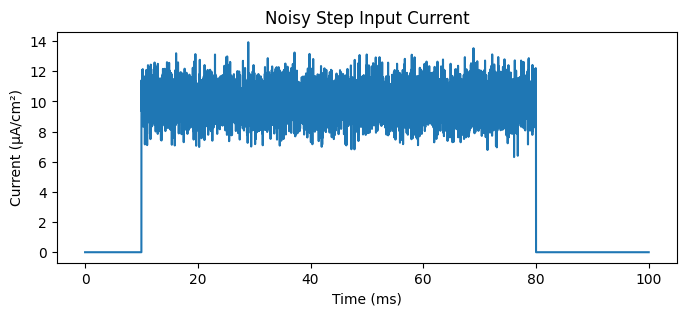

In [15]:
plt.figure(figsize=(8, 3))

plt.plot(time, I_ext)

plt.xlabel("Time (ms)")
plt.ylabel("Current (µA/cm²)")
plt.title("Noisy Step Input Current")
plt.show()

MEMBRANE POTENTIAL

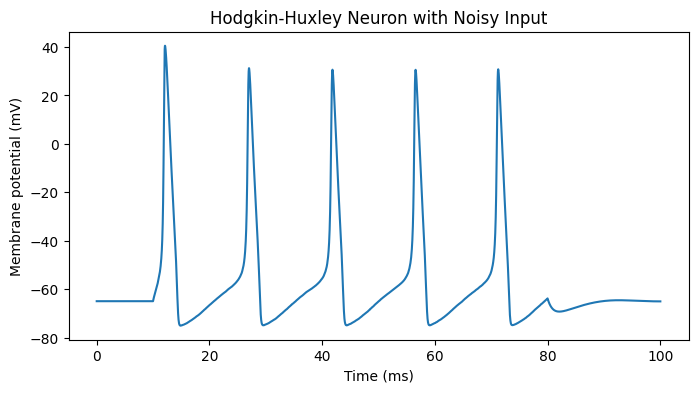

In [16]:
plt.figure(figsize=(8, 4))

plt.plot(time, V)

plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.title("Hodgkin-Huxley Neuron with Noisy Input")
plt.show()

PLOT H-H STATE VARIABLES

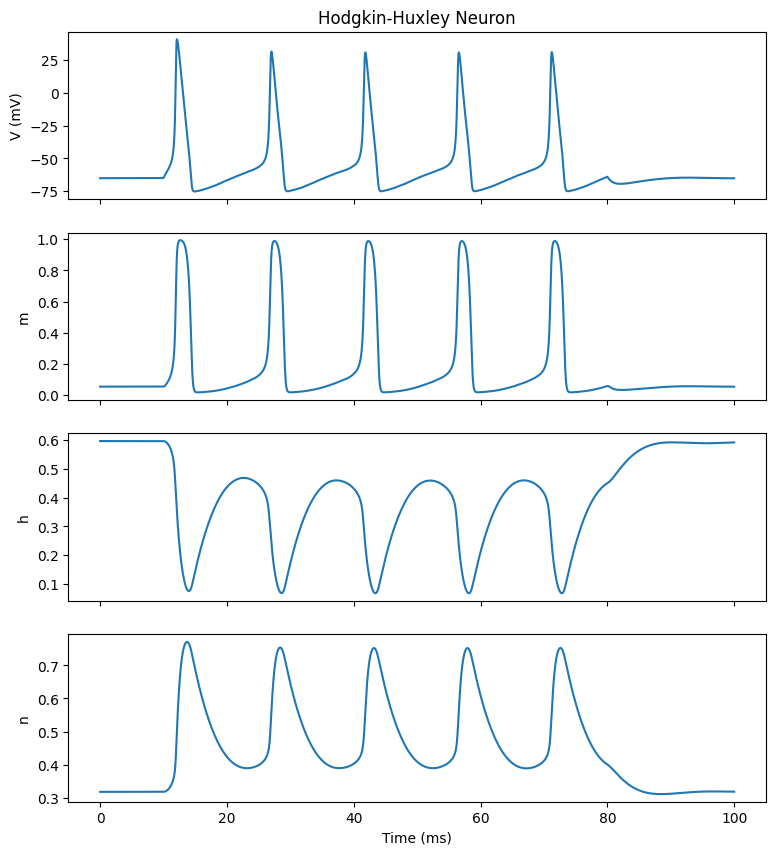

In [17]:
fig, axes = plt.subplots(4, 1, figsize=(9, 10), sharex=True)

# Membrane potential
axes[0].plot(time, V)
axes[0].set_ylabel("V (mV)")
axes[0].set_title("Hodgkin-Huxley Neuron")

# Sodium activation
axes[1].plot(time, m)
axes[1].set_ylabel("m")

# Sodium inactivation
axes[2].plot(time, h)
axes[2].set_ylabel("h")

# Potassium activation
axes[3].plot(time, n)
axes[3].set_ylabel("n")
axes[3].set_xlabel("Time (ms)")

plt.show()

TEMPORARILY CORRELATED NOISY INPUT CURRENT

In [18]:
np.random.seed(42)

I_ext = np.zeros(len(time))

# Stimulus parameters
I_mean = 10.0              # uA/cm^2
noise_std = 1.0            # uA/cm^2
tau_noise = 5.0            # ms

# OU noise
I_noise = np.zeros(len(time))

for i in range(1, len(time)):

    dI_noise = (
        -(I_noise[i-1] / tau_noise) * dt
        + noise_std * np.sqrt(2.0 * dt / tau_noise)
        * np.random.normal()
    )

    I_noise[i] = I_noise[i-1] + dI_noise


# Apply stimulus from 10 to 80 ms
stimulus = (time >= 10.0) & (time < 80.0)

I_ext[stimulus] = I_mean + I_noise[stimulus]

In [19]:
for i in range(1, len(time)):

    # Current at this time
    I = I_ext[i]

    # --------------------------------------------------------
    # 1. Calculate ionic currents
    # --------------------------------------------------------

    I_Na = g_Na * m[i-1]**3 * h[i-1] * (V[i-1] - E_Na)

    I_K = g_K * n[i-1]**4 * (V[i-1] - E_K)

    I_L = g_L * (V[i-1] - E_L)


    # --------------------------------------------------------
    # 2. Calculate membrane-potential change
    # --------------------------------------------------------

    dVdt = (I - I_Na - I_K - I_L) / c_m

    V[i] = V[i-1] + dt * dVdt


    # --------------------------------------------------------
    # 3. Calculate gating-variable changes
    # --------------------------------------------------------

    dm_dt = (
        alpha_m(V[i-1]) * (1.0 - m[i-1])
        - beta_m(V[i-1]) * m[i-1]
    )

    dh_dt = (
        alpha_h(V[i-1]) * (1.0 - h[i-1])
        - beta_h(V[i-1]) * h[i-1]
    )

    dn_dt = (
        alpha_n(V[i-1]) * (1.0 - n[i-1])
        - beta_n(V[i-1]) * n[i-1]
    )


    # --------------------------------------------------------
    # 4. Update gating variables
    # --------------------------------------------------------

    m[i] = m[i-1] + dt * dm_dt
    h[i] = h[i-1] + dt * dh_dt
    n[i] = n[i-1] + dt * dn_dt

CURRENT PLOT

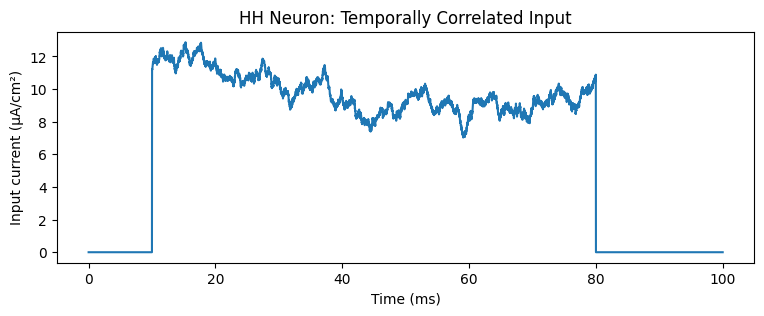

In [20]:
plt.figure(figsize=(9, 3))

plt.plot(time, I_ext)

plt.xlabel("Time (ms)")
plt.ylabel("Input current (µA/cm²)")
plt.title("HH Neuron: Temporally Correlated Input")
plt.show()

MEMBRANE PLOT

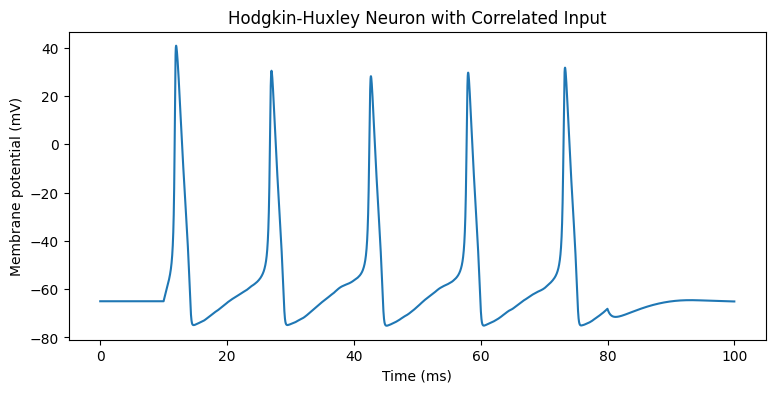

In [21]:
plt.figure(figsize=(9, 4))

plt.plot(time, V)

plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.title("Hodgkin-Huxley Neuron with Correlated Input")
plt.show()

In [22]:
# Spike detection

spike_threshold = 0.0   # mV

spike_indices = np.where(
    (V[:-1] < spike_threshold) &
    (V[1:] >= spike_threshold)
)[0]

spike_times = time[spike_indices]

print("Number of spikes:", len(spike_times))
print("Spike times (ms):", spike_times)

Number of spikes: 5
Spike times (ms): [11.73 26.76 42.43 57.77 73.05]


In [23]:
# Firing rate

stimulus_duration = 80.0 - 10.0    # ms

firing_rate = len(spike_times) / (stimulus_duration / 1000.0)

print(f"Firing rate: {firing_rate:.2f} Hz")

Firing rate: 71.43 Hz


In [24]:
# Inter-spike intervals

if len(spike_times) > 1:

    isi = np.diff(spike_times)

    print("Inter-spike intervals (ms):")
    print(isi)

    print(f"Mean ISI: {np.mean(isi):.2f} ms")

else:
    print("Not enough spikes to calculate ISI.")

Inter-spike intervals (ms):
[15.03 15.67 15.34 15.28]
Mean ISI: 15.33 ms


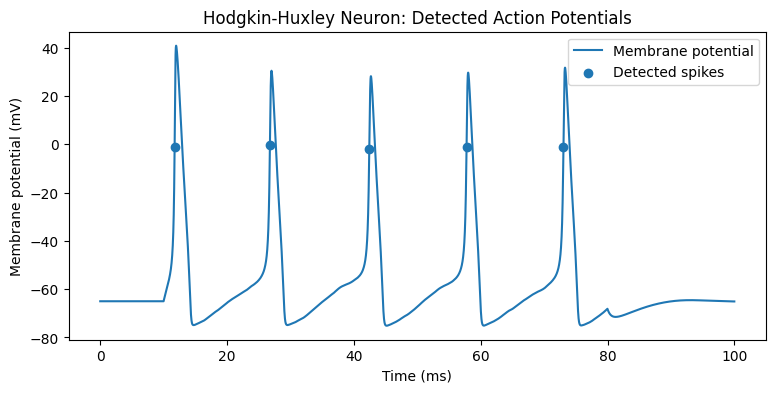

In [25]:
# Voltage trace with detected spikes

plt.figure(figsize=(9, 4))

plt.plot(time, V, label="Membrane potential")

plt.scatter(
    spike_times,
    V[spike_indices],
    marker="o",
    label="Detected spikes"
)

plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.title("Hodgkin-Huxley Neuron: Detected Action Potentials")
plt.legend()
plt.show()

In [26]:
def simulate_hh(I_ext):
    V = np.zeros(len(time))
    m = np.zeros(len(time))
    h = np.zeros(len(time))
    n = np.zeros(len(time))

    # Initial conditions
    V[0] = -65.0

    m[0] = alpha_m(V[0]) / (alpha_m(V[0]) + beta_m(V[0]))
    h[0] = alpha_h(V[0]) / (alpha_h(V[0]) + beta_h(V[0]))
    n[0] = alpha_n(V[0]) / (alpha_n(V[0]) + beta_n(V[0]))

    # HH simulation loop
    for i in range(1, len(time)):

        I = I_ext[i]

        # Ionic currents
        I_Na = g_Na * m[i-1]**3 * h[i-1] * (V[i-1] - E_Na)
        I_K = g_K * n[i-1]**4 * (V[i-1] - E_K)
        I_L = g_L * (V[i-1] - E_L)

        # Membrane potential
        dVdt = (I - I_Na - I_K - I_L) / c_m
        V[i] = V[i-1] + dt * dVdt

        # Gating variables
        dm_dt = (
            alpha_m(V[i-1]) * (1.0 - m[i-1])
            - beta_m(V[i-1]) * m[i-1]
        )

        dh_dt = (
            alpha_h(V[i-1]) * (1.0 - h[i-1])
            - beta_h(V[i-1]) * h[i-1]
        )

        dn_dt = (
            alpha_n(V[i-1]) * (1.0 - n[i-1])
            - beta_n(V[i-1]) * n[i-1]
        )

        m[i] = m[i-1] + dt * dm_dt
        h[i] = h[i-1] + dt * dh_dt
        n[i] = n[i-1] + dt * dn_dt

    return V, m, h, n

Input current -> Firing rate
0.0 µA/cm² -> 0.00 Hz
1.0 µA/cm² -> 0.00 Hz
2.0 µA/cm² -> 0.00 Hz
3.0 µA/cm² -> 10.00 Hz
4.0 µA/cm² -> 10.00 Hz
5.0 µA/cm² -> 10.00 Hz
6.0 µA/cm² -> 20.00 Hz
7.0 µA/cm² -> 60.00 Hz
8.0 µA/cm² -> 70.00 Hz
9.0 µA/cm² -> 70.00 Hz
10.0 µA/cm² -> 70.00 Hz
11.0 µA/cm² -> 70.00 Hz
12.0 µA/cm² -> 80.00 Hz
13.0 µA/cm² -> 80.00 Hz
14.0 µA/cm² -> 80.00 Hz
15.0 µA/cm² -> 80.00 Hz
16.0 µA/cm² -> 80.00 Hz
17.0 µA/cm² -> 90.00 Hz
18.0 µA/cm² -> 90.00 Hz
19.0 µA/cm² -> 90.00 Hz
20.0 µA/cm² -> 90.00 Hz


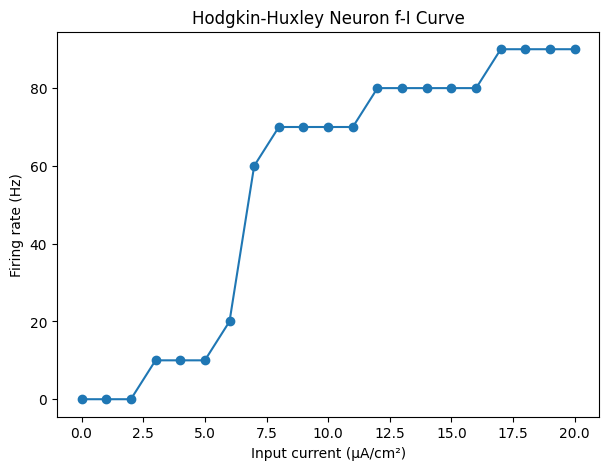

In [27]:
# f-I CURVE

currents = np.arange(0.0, 21.0, 1.0)
firing_rates = []

for I_value in currents:

    # Constant input current
    I_ext = np.full(len(time), I_value)

    # Simulate neuron
    V, m, h, n = simulate_hh(I_ext)

    # Detect spikes
    spike_indices = np.where(
        (V[:-1] < 0.0) &
        (V[1:] >= 0.0)
    )[0]

    # Calculate firing rate
    spike_count = len(spike_indices)

    firing_rate = spike_count / (T / 1000.0)

    # Store firing rate
    firing_rates.append(firing_rate)


# Print results

print("Input current -> Firing rate")

for I, rate in zip(currents, firing_rates):
    print(f"{I:.1f} µA/cm² -> {rate:.2f} Hz")


# Plot

plt.figure(figsize=(7, 5))

plt.plot(currents, firing_rates, marker="o")

plt.xlabel("Input current (µA/cm²)")
plt.ylabel("Firing rate (Hz)")
plt.title("Hodgkin-Huxley Neuron f-I Curve")
plt.show()